
======= 30-DAY READMISSION MODELS =======
Using 21 numeric features for LSTM

=== LSTM: 30-Day Readmission Training ===
Epoch 1/10


/Users/kunalmohindra/Lab-3-OMOP-on-FHIR/omopenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7033 - loss: 0.6032 - val_accuracy: 0.7515 - val_loss: 0.5032
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7709 - loss: 0.4740 - val_accuracy: 0.7726 - val_loss: 0.4672
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7771 - loss: 0.4698 - val_accuracy: 0.7873 - val_loss: 0.4611
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7980 - loss: 0.4475 - val_accuracy: 0.7965 - val_loss: 0.4475
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8001 - loss: 0.4386 - val_accuracy: 0.7999 - val_loss: 0.4475
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.4445 - val_accuracy: 0.8011 - val_loss: 0.4401
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8018 - loss: 0.4300 - val_accuracy: 0.7830 - val_loss: 0.4460
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8025 - loss: 0.4312 - val_accuracy: 0.8008 - val_

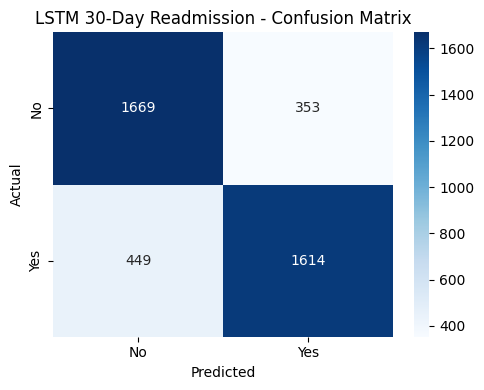

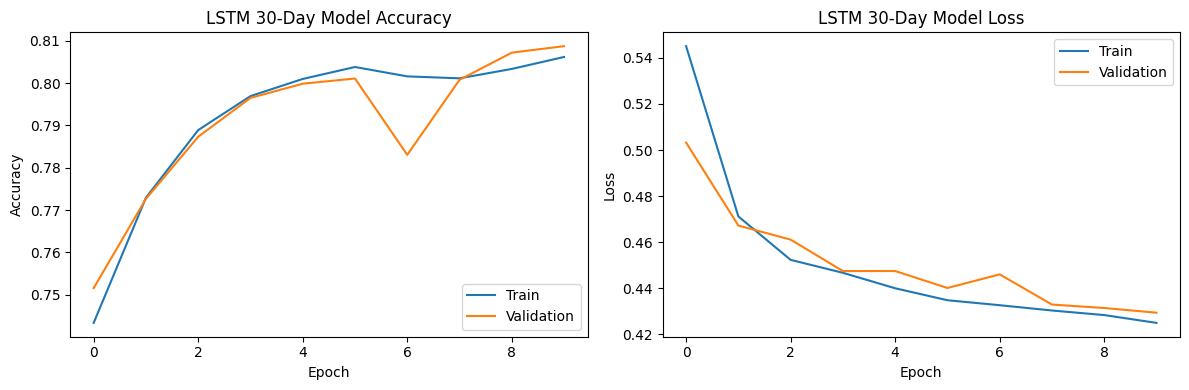


======= 60-DAY READMISSION MODELS =======
Using 21 numeric features for LSTM

=== LSTM: 60-Day Readmission Training ===
Epoch 1/10


/Users/kunalmohindra/Lab-3-OMOP-on-FHIR/omopenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7247 - loss: 0.5945 - val_accuracy: 0.7638 - val_loss: 0.5025
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7825 - loss: 0.4725 - val_accuracy: 0.7687 - val_loss: 0.4675
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7922 - loss: 0.4511 - val_accuracy: 0.7849 - val_loss: 0.4553
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7971 - loss: 0.4461 - val_accuracy: 0.7935 - val_loss: 0.4520
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8016 - loss: 0.4438 - val_accuracy: 0.7870 - val_loss: 0.4502
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8029 - loss: 0.4393 - val_accuracy: 0.7931 - val_loss: 0.4452
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7971 - loss: 0.4417 - val_accuracy: 0.7968 - val_loss: 0.4442
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8023 - loss: 0.4386 - val_accuracy: 0.7956 - val_

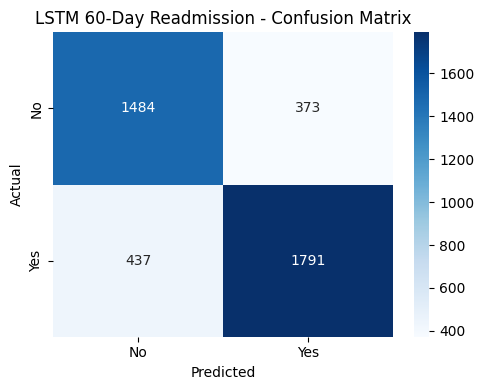

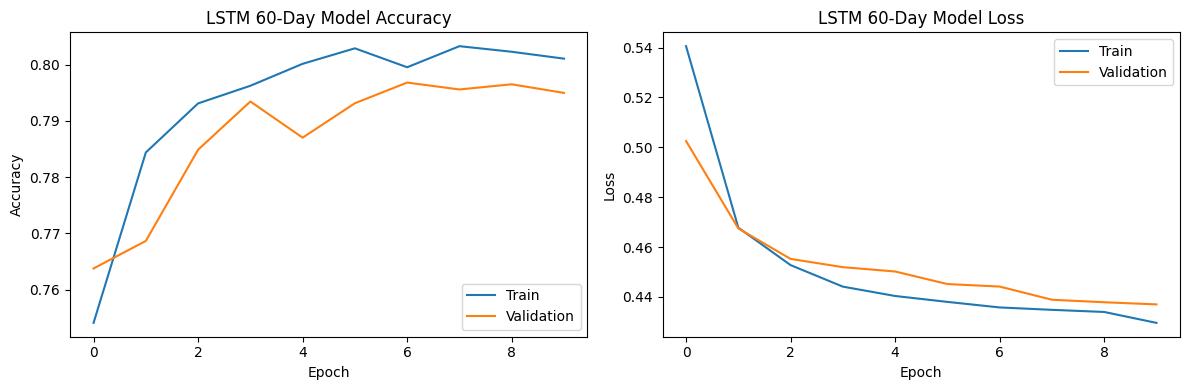

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv("readmission_dataset.csv")

# Shared features (exclude targets)
features = df.columns.difference(["readmitted_30_days", "readmitted_60_days"])

# Normalize numeric features
numeric_cols = df[features].select_dtypes(include=["float64", "int64"]).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Function to train and evaluate Random Forest model
def train_and_evaluate_rf(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n=== Random Forest: {label} Readmission ===")
    print(classification_report(y_test, y_pred))
    
    # ROC AUC Score
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"ROC AUC Score: {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"RF {label} Readmission - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return X_train, X_test, y_train, y_test

# Function to prepare data for LSTM - fixed version
def prepare_data_for_lstm(X_train, X_test):
    # Filter out non-numeric columns
    numeric_cols = X_train.select_dtypes(include=["float64", "int64"]).columns
    
    # Print which columns we're using
    print(f"Using {len(numeric_cols)} numeric features for LSTM")
    
    # Use only numeric columns
    X_train_numeric = X_train[numeric_cols]
    X_test_numeric = X_test[numeric_cols]
    
    # Reshape data for LSTM input: [samples, time steps, features]
    X_train_lstm = X_train_numeric.values.reshape(X_train_numeric.shape[0], 1, X_train_numeric.shape[1])
    X_test_lstm = X_test_numeric.values.reshape(X_test_numeric.shape[0], 1, X_test_numeric.shape[1])
    
    return X_train_lstm, X_test_lstm

# Function to train and evaluate LSTM model
def train_and_evaluate_lstm(X_train, X_test, y_train, y_test, label):
    # Reshape data for LSTM
    X_train_lstm, X_test_lstm = prepare_data_for_lstm(X_train, X_test)
    
    # Build LSTM model
    model = Sequential([
        LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # Train model
    print(f"\n=== LSTM: {label} Readmission Training ===")
    history = model.fit(
        X_train_lstm, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Evaluate model
    y_pred_proba = model.predict(X_test_lstm)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    print(f"\n=== LSTM: {label} Readmission Results ===")
    print(classification_report(y_test, y_pred))
    
    # ROC AUC Score
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"LSTM {label} Readmission - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'LSTM {label} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'LSTM {label} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return model

# Create the training and test data first
X_all = df[features]

# Split data for 30-day readmission
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_all, df["readmitted_30_days"], test_size=0.2, random_state=42
)

# Split data for 60-day readmission
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X_all, df["readmitted_60_days"], test_size=0.2, random_state=42
)

# Now you can train the LSTM models
print("\n======= 30-DAY READMISSION MODELS =======")
lstm_model_30 = train_and_evaluate_lstm(X_train_30, X_test_30, y_train_30, y_test_30, "30-Day")

print("\n======= 60-DAY READMISSION MODELS =======")
lstm_model_60 = train_and_evaluate_lstm(X_train_60, X_test_60, y_train_60, y_test_60, "60-Day")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
